# Modelo por regresión lineal múltiple

In [1]:
## CARGA DE LIBRERIAS ##
import pandas as pd
import numpy as np
import matplotlib as plt #?
import seaborn as sns #?
import pickle

In [2]:
## CARGA DE DATASET ##
df = pd.read_csv('~/Documents/Universidad/TFM/TFM_imarcospu/Dataset/dataset_sdn.csv') # Ver si se puede hacer una carga mediante pickle para no tener que cargar el fichero de forma local
# Observamos los primeros datos
df.head(5)

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


La variable objetivo que se encargará de realizar las predicciones de tráfico será tot_kbps, que indica el total de ancho de banda utilizado en dicha traza de tráfico. De esta forma, dada una traza, el controlador SDN podrá asignar un ancho de banda específico para dicha transmisión, gestionando y adaptando los recursos de red de una forma mucho más eficiente. El dataset cuenta con una columna label que actúa como un flag que toma valores 0 o 1, realizando una diferenciación en dos clases de tráfico: normal y de ataque. Dado que nuestro objetivo con este modelo es realizar predicciones de tráfico, escogemos únicamente las trazas que sean de tráfico normal, excluyendo el tráfico de ataque.

,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,101000000000.0,3,1943,13535,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,281000000000.0,2,1943,13531,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,201000000000.0,3,1943,13534,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,201000000000.0,3,1943,13534,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,201000000000.0,3,1943,13534,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89810,10.0.0.5,10.0.0.7,79,7742,81,842000000,81842000000.0,5,10,29,...,0,0,ICMP,1,15209,12720,1,1.0,2.0,0
89811,10.0.0.5,10.0.0.7,79,7742,81,842000000,81842000000.0,5,10,29,...,0,0,ICMP,3,15099,14693,1,1.0,2.0,0
89812,10.0.0.11,10.0.0.5,31,3038,31,805000000,31805000000.0,5,10,30,...,1,0,ICMP,2,3409,3731,0,0.0,0.0,0
89813,10.0.0.11,10.0.0.5,31,3038,31,805000000,31805000000.0,5,10,30,...,1,0,ICMP,1,15209,12720,1,1.0,2.0,0


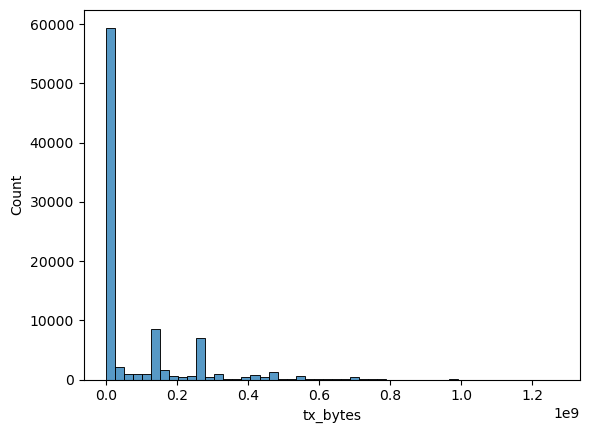

In [3]:
# filtramos datos de tot_kbps 
df = df[
        df['tot_kbps'] <= 5000
        ]
# eliminamos columna switch y host ya que tampoco aportan información relevante ya que el origen y destino viene dado
# por src_ip y dst_ip
del df['dt']
del df['switch']

columnas = df.columns
# eliminamos valores nulos
df.isnull().sum()
df = df[columnas].fillna(0).values

df = pd.DataFrame(df, columns=columnas)
df.isnull().sum()

sns.histplot(df.tx_bytes, bins=50)

df

## Datos de entrenamiento/validación/test

Para elaborar y validar el modelo, dividimos la totalidad de los datos en tres partes: 60% para entrenar el modelo, un 20% para validarlo y otro 20% para testear el modelo. Después debemos excluir la variable objetivo del dataframe, así evitaremos utilizarla para los cálculos del modelo.

In [4]:
n = len(df) # numero de registros

n_val = int(n*0.2) # numero de registros para validacion
n_test = int(n*0.2) # numero de registros para test
n_train = n - n_val - n_test # numero de registros para entrenamiento

# escogemos los registros acordados del dataframe
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

# barajamos los datos para evitar linealidades estadísticas (datos no consecutivos)

index = np.arange(n) # vector de 0 hasta n
np.random.seed(5) # establecemos semilla
np.random.shuffle(index) # barajamos el vector

# barajamos el dataframe
df_train = df.iloc[index[:n_train]]
df_val = df.iloc[index[n_train:n_train+n_val]]
df_test = df.iloc[index[n_train+n_val:]]

# reseteamos indices para que vayan de 0 a n_*
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_val.reset_index(drop=True)

# seleccionamos nuestra variable objetivo del dataframe
y_train = df_train.tot_kbps.values
y_val = df_val.tot_kbps.values
y_test = df_test.tot_kbps.values

# eliminamos del dataframe la variable objetivo, evitando utilizarla para los cálculos del modelo
del df_train['tot_kbps']
del df_val['tot_kbps']
del df_test['tot_kbps']

## Análisis exploratorio de datos

Debemos realizar un análisis al dataframe obtenido, comprobando que no tenga datos erróneos que nos entorpezcan a la hora de realizar el modelo. Comprobaremos el nombre de las columnas, el tipo y la codificación de las mismas, así como el escalado (normalización) de los datos. Encapsulamos todo en una función para aplicar a los tres tipos de dataframes

In [5]:
from sklearn.preprocessing import StandardScaler

def prepara_X(df):
    df = df.copy()
    
    # ponemos nombres de columna en minuscula
    df.columns = df.columns.str.lower()
    df.columns
    
    # observamos las cabeceras y sus tipos, viendo que hay tres campos que son de tipo object (src_ip, dst_ip, protocol)
    # se tratan de variables categóricas (string) que debemos transformar para que nuestro modelo ML lo pueda interpretar
    df.dtypes
    
    # vemos que solo hay 24 direcciones IP en total, mientras que protocolos solo hay tres.
    df[['src','dst','protocol']].nunique()
    
    # realizamos codificaciones para la columna protocol mediante one-hot encoding. 
    df['protocol_tcp'] = (df.protocol == 'TCP').astype('int')
    df['protocol_udp'] = (df.protocol == 'UDP').astype('int')
    df['protocol_icmp'] = (df.protocol == 'ICMP').astype('int')
        
    del df['protocol']
    
    df['src_ip_1'] = (df.src == '10.0.0.1').astype('int')
    df['src_ip_2'] = (df.src == '10.0.0.2').astype('int')
    df['src_ip_3'] = (df.src == '10.0.0.3').astype('int')
    df['src_ip_4'] = (df.src == '10.0.0.4').astype('int')
    df['src_ip_5'] = (df.src == '10.0.0.5').astype('int')
    df['src_ip_6'] = (df.src == '10.0.0.6').astype('int')
    df['src_ip_7'] = (df.src == '10.0.0.7').astype('int')
    df['src_ip_8'] = (df.src == '10.0.0.8').astype('int')
    df['src_ip_9'] = (df.src == '10.0.0.9').astype('int')
    df['src_ip_10'] = (df.src == '10.0.0.10').astype('int')
    df['src_ip_11'] = (df.src == '10.0.0.11').astype('int')
    df['src_ip_12'] = (df.src == '10.0.0.12').astype('int')
    df['src_ip_13'] = (df.src == '10.0.0.13').astype('int')
    df['src_ip_14'] = (df.src == '10.0.0.14').astype('int')
    df['src_ip_15'] = (df.src == '10.0.0.15').astype('int')
    df['src_ip_16'] = (df.src == '10.0.0.16').astype('int')
    df['src_ip_17'] = (df.src == '10.0.0.17').astype('int')
    df['src_ip_18'] = (df.src == '10.0.0.18').astype('int')
    df['src_ip_20'] = (df.src == '10.0.0.20').astype('int')
    
    del df['src']

    df['dst_ip_1'] = (df.dst == '10.0.0.1').astype('int')
    df['dst_ip_2'] = (df.dst == '10.0.0.2').astype('int')
    df['dst_ip_3'] = (df.dst == '10.0.0.3').astype('int')
    df['dst_ip_4'] = (df.dst == '10.0.0.4').astype('int')
    df['dst_ip_5'] = (df.dst == '10.0.0.5').astype('int')
    df['dst_ip_6'] = (df.dst == '10.0.0.6').astype('int')
    df['dst_ip_7'] = (df.dst == '10.0.0.7').astype('int')
    df['dst_ip_8'] = (df.dst == '10.0.0.8').astype('int')
    df['dst_ip_9'] = (df.dst == '10.0.0.9').astype('int')
    df['dst_ip_10'] = (df.dst == '10.0.0.10').astype('int')
    df['dst_ip_11'] = (df.dst == '10.0.0.11').astype('int')
    df['dst_ip_12'] = (df.dst == '10.0.0.12').astype('int')
    df['dst_ip_13'] = (df.dst == '10.0.0.13').astype('int')
    df['dst_ip_14'] = (df.dst == '10.0.0.14').astype('int')
    df['dst_ip_15'] = (df.dst == '10.0.0.15').astype('int')
    df['dst_ip_16'] = (df.dst == '10.0.0.16').astype('int')
    df['dst_ip_17'] = (df.dst == '10.0.0.17').astype('int')
    df['dst_ip_18'] = (df.dst == '10.0.0.18').astype('int')
    
    del df['dst']

    # estandarizamos todos nuestros datos menos las variables binarias con StandardScaler()
    features_num = ['pktcount', 'bytecount', 'dur', 'dur_nsec', 'tot_dur',
                   'flows', 'packetins', 'pktperflow', 'byteperflow', 'pktrate', 
                   'port_no', 'tx_bytes', 'rx_bytes', 'tx_kbps']
    features_cat = ['protocol_tcp',
           'protocol_udp', 'protocol_icmp', 'src_ip_1', 'src_ip_2', 'src_ip_3',
           'src_ip_4', 'src_ip_5', 'src_ip_6', 'src_ip_7', 'src_ip_8', 'src_ip_9',
           'src_ip_10', 'src_ip_11', 'src_ip_12', 'src_ip_13', 'src_ip_14',
           'src_ip_15', 'src_ip_16', 'src_ip_17', 'src_ip_18', 'src_ip_20', 
           'dst_ip_1', 'dst_ip_2', 'dst_ip_3', 'dst_ip_4', 'dst_ip_5', 'dst_ip_6',
           'dst_ip_7', 'dst_ip_8', 'dst_ip_9', 'dst_ip_10', 'dst_ip_11',
           'dst_ip_12', 'dst_ip_13', 'dst_ip_14', 'dst_ip_15', 'dst_ip_16',
           'dst_ip_17', 'dst_ip_18']
    
    df_num = df[features_num]
    df_cat = df[features_cat]
    
    normalizador = StandardScaler()
    df_norm = normalizador.fit_transform(df_num[features_num])

    # concatenamos
    columnas = features_num + features_cat
    X = pd.DataFrame(np.concatenate([df_norm, df_cat], axis=1), columns=columnas)
    
    return X

## Entrenamiento del modelo de regresion lineal

Un modelo lineal debe seguirse por la fórmula de regresión lineal (ver memoria ...)

In [6]:
# error cuadratico medio
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()

    return np.sqrt(mse)

np.float64(659.7629649315373)

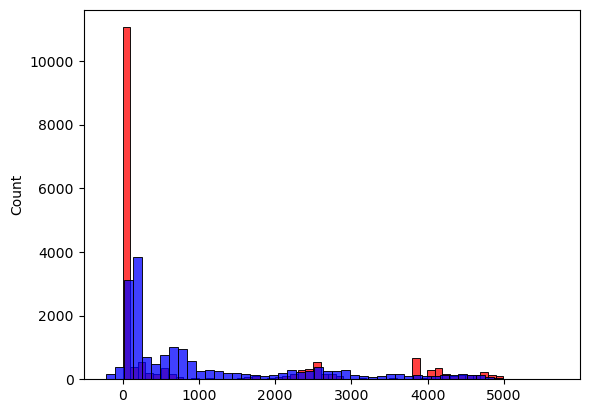

In [7]:
# pasamos a obtener las predicciones del modelo
#X_train = prepara_X(df_train) # entrenamos
#w0, w = modelo_reg_lineal(X_train, y_train, r=0.0001)

#X_val = prepara_X(df_val) # validamos
#y_pred = w0 + X_val.dot(w) # validamos
#rmse(y_val, y_pred)

from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()

X_train = prepara_X(df_train)
X_val = prepara_X(df_val)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)
rmse = rmse(y_val,y_pred)

sns.histplot(y_val, color='red', bins=50)
sns.histplot(y_pred, color='blue', bins=50)

rmse